# Giai đoạn 0
### Khảo sát và Hiểu Bộ Dữ liệu CWRU

**Mục lục:**
1. [01 — Dataset Overview](#01) (mục 0.1)
2. [02 — Time Domain Analysis](#02) (mục 0.2a)
3. [03 — Frequency Domain Analysis](#03) (mục 0.2b)
4. [04 — Order-Domain Analysis](#04) (mục 1.2)
5. [05 — Envelope Analysis](#05) (mục 1.3)
6. [06 — Window Leakage Analysis](#06) (mục 0.3a)
7. [07 — LOLO Visualization](#07) (mục 0.3b/2.1)
8. [08 — Summary & Research Questions](#08) (mục 0.4)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from typing import Any
from matplotlib.patches import Rectangle

from common import io_utils, pipeline, synthetic, dsp, features, splitting, config as cfg

pd.set_option("display.max_colwidth", 120)

In [2]:
# ============================== CẤU HÌNH ==============================
# Đổi USE_SYNTHETIC_DATA = False và chỉnh REAL_DATA_ROOT khi đã có dữ liệu
# CWRU thật. Xem README.md phần "Chuyển sang dữ liệu thật".
USE_SYNTHETIC_DATA = False
REAL_DATA_ROOT = Path("../../data/raw")            # <-- data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = True
# ========================================================================

In [3]:
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

---

<a id="01"></a>

## 01 — Dataset Overview
### Mục 0.1 của đề cương — Khảo sát cấu trúc bộ dữ liệu CWRU

**Mục đích**: quét thư mục dữ liệu, dựng bảng manifest (nhãn, tải, đường
kính lỗi, vị trí cảm biến...), và chạy các sanity check quan trọng đã xác
định ở phần Tổng quan đề tài:

1. Sampling rate của file Normal baseline (nhiều nguồn không thống nhất
   12kHz hay 48kHz).
2. Đường kính lỗi 0.028"/0.040" dùng vòng bi **NTN**, khác SKF 6205 dùng
   cho 0.007"/0.014"/0.021".
3. Outer Race có 3 vị trí lỗi (6h/3h/12h) — đề tài chỉ dùng vị trí
   **Centered (6h)**.
4. RPM thực tế trong file có khớp RPM danh định theo tải hay không.

**Trước khi chạy với dữ liệu thật**: mở `common/io_utils.py`, chỉnh hàm
`parse_metadata_from_filename()` cho khớp cấu trúc thư mục/tên file bạn
đang có — file `.mat` gốc CWRU chỉ có tên số, không tự chứa metadata.

In [4]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,None,,False
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,None,,False
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,None,,False
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,None,,False
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,None,,False


## Thống kê số file theo (nhãn × tải)

In [5]:
pivot = manifest.pivot_table(
    index="label", columns="load_hp", values="file_path",
    aggfunc="count", fill_value=0,
)
print(pivot)
pivot.to_csv(TABLES_DIR / "01_label_load_pivot.csv")

load_hp   0   1   2   3
label                  
B        10  10  10  10
IR       10  10  10  10
Normal    1   1   1   1
OR       20  19  19  19


## Cảnh báo sanity check

Mỗi dòng cảnh báo cần được đọc và quyết định xử lý (giữ/loại/sửa) — script chỉ phát hiện

In [6]:
n_warn = int(manifest["has_warning"].sum())
print(f"Số file có cảnh báo: {n_warn} / {len(manifest)}\n")

if n_warn > 0:
    warn_cols = ["file_path", "label", "load_hp", "fault_diameter_mils", "warnings"]
    warn_df = manifest.loc[manifest["has_warning"], warn_cols]
    warn_df.to_csv(TABLES_DIR / "01_warnings.csv", index=False)
    display(warn_df)
else:
    print("Không có cảnh báo nào trên bộ dữ liệu hiện tại.")

Số file có cảnh báo: 125 / 161



,file_path,label,load_hp,fault_diameter_mils,warnings
12,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\028\3005_0.mat,B,0,28.0,"VONG_BI_NTN: đường kính 28 mils dùng vòng bi NTN, KHÔNG dùng hình học SKF 6205 để tính BPFO/BPFI/BSF."
13,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\028\3006_1.mat,B,1,28.0,"VONG_BI_NTN: đường kính 28 mils dùng vòng bi NTN, KHÔNG dùng hình học SKF 6205 để tính BPFO/BPFI/BSF."
14,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\028\3007_2.mat,B,2,28.0,"VONG_BI_NTN: đường kính 28 mils dùng vòng bi NTN, KHÔNG dùng hình học SKF 6205 để tính BPFO/BPFI/BSF."
15,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\028\3008_3.mat,B,3,28.0,"VONG_BI_NTN: đường kính 28 mils dùng vòng bi NTN, KHÔNG dùng hình học SKF 6205 để tính BPFO/BPFI/BSF."
28,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\IR\028\3001_0.mat,IR,0,28.0,"VONG_BI_NTN: đường kính 28 mils dùng vòng bi NTN, KHÔNG dùng hình học SKF 6205 để tính BPFO/BPFI/BSF."
...,...,...,...,...,...
156,..\..\data\raw\48k_Drive_End_Bearing_Fault_Data\OR\021\@6\241_3.mat,OR,3,21.0,"NGOAI_PHAM_VI_TAN_SO_KHAI_BAO: file thuộc nhóm khai báo 48.0kHz, phạm vi đã chốt chỉ dùng 12kHz."
157,..\..\data\raw\Normal\100_Normal_3.mat,Normal,3,NaN,"NGHI_NGO_SAMPLING_RATE: n_samples=485643 (12kHz->40.5s, 24kHz->20.2s, 48kHz->10.1s). Rate hợp lý nhất: 48kHz — KHÁC ..."
158,..\..\data\raw\Normal\97_Normal_0.mat,Normal,0,NaN,"NGHI_NGO_SAMPLING_RATE: n_samples=243938 (12kHz->20.3s, 24kHz->10.2s, 48kHz->5.1s). Rate hợp lý nhất: 24kHz — KHÁC r..."
159,..\..\data\raw\Normal\98_Normal_1.mat,Normal,1,NaN,"NGHI_NGO_SAMPLING_RATE: n_samples=483903 (12kHz->40.3s, 24kHz->20.2s, 48kHz->10.1s). Rate hợp lý nhất: 48kHz — KHÁC ..."


## Tự kiểm chứng sanity check (bonus)

Phần dưới đây tạo riêng 4 file `.mat` **cố ý gài lỗi** (tách biệt hoàn
toàn khỏi `manifest` ở trên) để xác nhận cả 4 loại sanity check thực sự
hoạt động, trước khi bạn tin tưởng dùng chúng trên dữ liệu thật.

In [7]:
edge_root, expected_keywords = synthetic.build_edge_case_dataset(Path("./_data/edge_cases"))
edge_manifest = io_utils.build_manifest(edge_root)

all_warnings_text = " ".join(edge_manifest["warnings"].tolist())
print("Kiểm tra từng loại cảnh báo có xuất hiện không:\n")
all_ok = True
for kw in expected_keywords:
    found = kw in all_warnings_text
    print(f"  [{'CÓ' if found else 'THIẾU'}] {kw}")
    all_ok = all_ok and found

print("\nToàn bộ sanity check hoạt động đúng." if all_ok else
      "\nCó sanity check chưa hoạt động như mong đợi — kiểm tra lại common/io_utils.py.")

Kiểm tra từng loại cảnh báo có xuất hiện không:

  [CÓ] NGHI_NGO_SAMPLING_RATE
  [CÓ] OR_NGOAI_PHAM_VI
  [CÓ] VONG_BI_NTN
  [CÓ] RPM_LECH
  [CÓ] NGOAI_PHAM_VI_CAM_BIEN
  [CÓ] NGOAI_PHAM_VI_TAN_SO_KHAI_BAO

Toàn bộ sanity check hoạt động đúng.


## Checklist trước khi sang notebook 02

- [ ] Đã chỉnh `parse_metadata_from_filename()` khớp với dữ liệu thật.
- [ ] Đã đọc hết `outputs/tables/01_warnings.csv`, quyết định rõ giữ/loại
      từng trường hợp.
- [ ] Đã đối chiếu ngẫu nhiên vài dòng manifest với bảng tra cứu gốc trên
      trang CWRU Bearing Data Center để xác nhận parse đúng.

---

<a id="02"></a>

## 02 — Time Domain Analysis
### Phần đầu của mục 0.2 — So sánh dạng sóng miền thời gian

**Mục đích**: so sánh trực quan dạng sóng của 4 nhãn (Normal, Inner Race,
Outer Race, Ball) tại **cùng một mức tải**, quan sát sự khác biệt về biên
độ và tính xung (impulsiveness) — lỗi cơ khí thường biểu hiện dưới dạng
các xung lặp lại theo chu kỳ, trong khi Normal thì không.

In [8]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,None,,False
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,None,,False
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,None,,False
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,None,,False
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,None,,False


## Lọc phạm vi dữ liệu (mục 0.1/0.4) — TRƯỚC khi phân tích

`manifest` gốc còn chứa cả file NGOÀI phạm vi đã chốt (vòng bi NTN đường
kính 28/40 mils, vị trí Outer Race Orthogonal/Opposite). Nếu không lọc ở
đây, các bước chọn "file đại diện" bên dưới có thể vô tình chọn nhầm — vd
chọn file OR vị trí Orthogonal/Opposite trong khi đề tài chỉ dùng Centered.

In [9]:
manifest = io_utils.apply_scope_filter(manifest)

Áp dụng bộ lọc phạm vi (mục 0.1/0.4):
  - Loại 8 file có cảnh báo 'VONG_BI_NTN'
  - Loại 47 file có cảnh báo 'OR_NGOAI_PHAM_VI'
  - Loại 0 file có cảnh báo 'OR_THIEU_VI_TRI'
  - Loại 0 file có cảnh báo 'THIEU_NHAN'
  - Loại 0 file có cảnh báo 'THIEU_TAI'
  - Loại 0 file có cảnh báo 'DUONG_KINH_LA'
  - Loại 45 file có cảnh báo 'NGOAI_PHAM_VI_CAM_BIEN'
  - Loại 52 file có cảnh báo 'NGOAI_PHAM_VI_TAN_SO_KHAI_BAO'
  - Loại 0 file có cảnh báo 'THIEU_TIN_HIEU_DE'
  - Loại 0 file có cảnh báo 'LOI_DOC_FILE'
Tổng: loại 121/161 file — còn lại 40 file.


## Chọn 1 file đại diện mỗi nhãn, cùng mức tải

In [10]:
LOAD_HP = 0  # đổi mức tải muốn xem tại đây

labels_to_plot = ["Normal", "IR", "OR", "B"]
signals = {}
for label in labels_to_plot:
    fp = pipeline.pick_file(manifest, label=label, load_hp=LOAD_HP)
    signals[label] = io_utils.load_de_signal(Path(fp))
    print(f"{label:8s}: {fp}  ({len(signals[label])} mẫu)")

Normal  : ..\..\data\raw\Normal\97_Normal_0.mat  (243938 mẫu)
IR      : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\IR\007\105_0.mat  (121265 mẫu)
OR      : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\OR\007\@6\130@6_0.mat  (121991 mẫu)
B       : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat  (122571 mẫu)


## Vẽ chồng dạng sóng ở miền thời gian

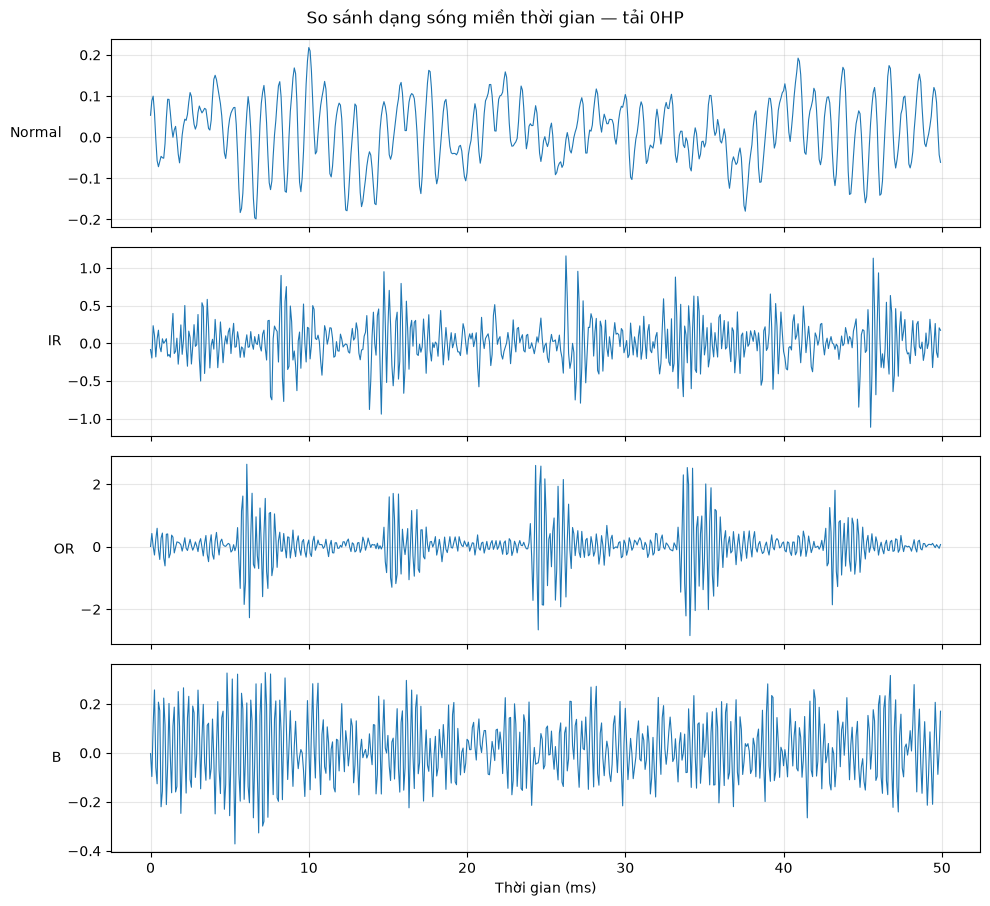

In [11]:
FS = 12000  # sampling rate của dữ liệu đang phân tích (đổi nếu khác)
N_SECONDS = 0.05  # chỉ xem 50ms đầu cho dễ quan sát tính xung

fig, axes = plt.subplots(len(signals), 1, figsize=(10, 2.3 * len(signals)), sharex=True)
n_samples_plot = int(N_SECONDS * FS)
t_ms = np.arange(n_samples_plot) / FS * 1000

for ax, (label, x) in zip(axes, signals.items()):
    ax.plot(t_ms, x[:n_samples_plot], linewidth=0.8)
    ax.set_ylabel(label, rotation=0, ha="right", va="center")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Thời gian (ms)")
fig.suptitle(f"So sánh dạng sóng miền thời gian — tải {LOAD_HP}HP")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_time_domain_comparison.png", dpi=150)
plt.show()

## Quan sát

Điền nhận xét thực tế sau khi chạy với dữ liệu CWRU thật:
- Nhãn nào có biên độ đỉnh (peak) lớn nhất?
- Nhãn nào thể hiện rõ tính xung (các đỉnh nhọn lặp lại theo chu kỳ) nhất?
- Normal có đặc điểm gì khác biệt rõ rệt so với 3 nhãn lỗi?

Hình đã lưu tại `outputs/figures/02_time_domain_comparison.png` — dùng
trực tiếp cho phần Cơ sở lý thuyết của báo cáo.

---

<a id="03"></a>

## 03 — Frequency Domain Analysis (FFT)
### Phần thứ hai của mục 0.2 — Phổ FFT, quan sát đỉnh dịch chuyển theo tải

**Mục đích**: vẽ FFT của cùng một loại lỗi qua các mức tải khác nhau, quan
sát các đỉnh phổ **dịch chuyển vị trí** trên trục Hz khi tải thay đổi (vì
tốc độ quay động cơ thay đổi theo tải) — đây chính là lý do cần Order-domain
Normalization ở notebook 04.

Notebook này cũng dùng để **chọn dải bandpass cho Square-Law Demodulation**
ở notebook 05 — quan sát vùng tần số có biên độ nổi bật nhất trên file có
lỗi rõ ràng.

In [12]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,None,,False
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,None,,False
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,None,,False
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,None,,False
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,None,,False


## Lọc phạm vi dữ liệu (mục 0.1/0.4) — TRƯỚC khi phân tích

`manifest` gốc còn chứa cả file NGOÀI phạm vi đã chốt (vòng bi NTN đường
kính 28/40 mils, vị trí Outer Race Orthogonal/Opposite). Nếu không lọc ở
đây, các bước chọn "file đại diện" bên dưới có thể vô tình chọn nhầm — vd
chọn file OR vị trí Orthogonal/Opposite trong khi đề tài chỉ dùng Centered.

In [13]:
manifest = io_utils.apply_scope_filter(manifest)

Áp dụng bộ lọc phạm vi (mục 0.1/0.4):
  - Loại 8 file có cảnh báo 'VONG_BI_NTN'
  - Loại 47 file có cảnh báo 'OR_NGOAI_PHAM_VI'
  - Loại 0 file có cảnh báo 'OR_THIEU_VI_TRI'
  - Loại 0 file có cảnh báo 'THIEU_NHAN'
  - Loại 0 file có cảnh báo 'THIEU_TAI'
  - Loại 0 file có cảnh báo 'DUONG_KINH_LA'
  - Loại 45 file có cảnh báo 'NGOAI_PHAM_VI_CAM_BIEN'
  - Loại 52 file có cảnh báo 'NGOAI_PHAM_VI_TAN_SO_KHAI_BAO'
  - Loại 0 file có cảnh báo 'THIEU_TIN_HIEU_DE'
  - Loại 0 file có cảnh báo 'LOI_DOC_FILE'
Tổng: loại 121/161 file — còn lại 40 file.


## FFT của cùng 1 loại lỗi qua các mức tải (trục Hz)

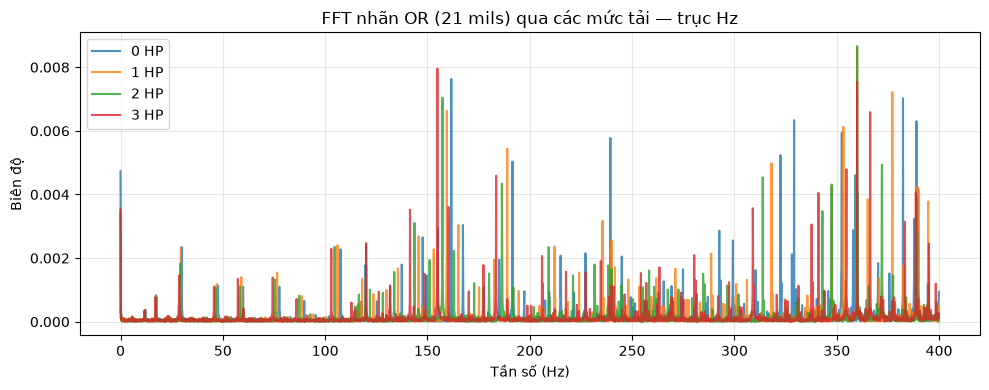

In [14]:
FAULT_LABEL = "OR"       # đổi nhãn muốn xem: "IR", "OR", "B"
DIAMETER_MILS = 21       # đường kính lỗi muốn xem (7/14/21 — trong phạm vi SKF)
FREQ_MAX_HZ = 400

fig, ax = plt.subplots(figsize=(10, 4))
signals_by_load = {}
for load_hp in sorted(manifest["load_hp"].dropna().unique()):
    load_hp = int(load_hp)
    try:
        fp = pipeline.pick_file(manifest, label=FAULT_LABEL, load_hp=load_hp, diameter_mils=DIAMETER_MILS)
    except ValueError:
        continue
    x = io_utils.load_de_signal(Path(fp))
    signals_by_load[load_hp] = x
    freqs, mag = dsp.compute_fft(x, fs=12000)
    mask = freqs <= FREQ_MAX_HZ
    ax.plot(freqs[mask], mag[mask], label=f"{load_hp} HP", alpha=0.8)

ax.set_xlabel("Tần số (Hz)")
ax.set_ylabel("Biên độ")
ax.set_title(f"FFT nhãn {FAULT_LABEL} ({DIAMETER_MILS} mils) qua các mức tải — trục Hz")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_fft_hz_across_loads.png", dpi=150)
plt.show()

## Đối chiếu với tần số lỗi lý thuyết

So vị trí đỉnh phổ quan sát được ở trên với BPFO/BPFI/BSF lý thuyết
(công thức SKF 6205, `common/config.py`) tại từng mức tải.

In [15]:
rows = []
for load_hp in sorted(signals_by_load.keys()):
    rpm = cfg.NOMINAL_RPM_BY_LOAD.get(load_hp)
    if rpm is None:
        continue
    freqs = cfg.bearing_fault_frequencies(rpm)
    rows.append({"load_hp": load_hp, "rpm_danh_dinh": rpm, **freqs})

theoretical_df = pd.DataFrame(rows).round(2)
theoretical_df.to_csv(TABLES_DIR / "03_theoretical_fault_freq_by_load.csv", index=False)
theoretical_df

,load_hp,rpm_danh_dinh,f_rot,BPFO,BPFI,BSF,FTF
0,0,1797,29.95,107.36,162.19,70.58,11.93
1,1,1772,29.53,105.87,159.93,69.60,11.76
2,2,1750,29.17,104.56,157.94,68.74,11.62
3,3,1730,28.83,103.36,156.14,67.95,11.48


## Quan sát

- Đỉnh phổ có dịch chuyển theo tải như bảng lý thuyết dự đoán không?
- Ghi lại dải tần số có biên độ nổi bật nhất (thường quanh vùng cộng hưởng
  cơ khí) — dùng làm điểm khởi đầu để chọn `band` cho Square-Law
  Demodulation ở notebook 05.

Hình đã lưu tại `outputs/figures/03_fft_hz_across_loads.png`.

---

<a id="04"></a>

## 04 — Order-Domain Analysis
### Mục 1.2 (minh chứng ở mục 0.2) — Order Normalization

**Mục đích**: chuyển trục tần số Hz sang trục bậc quay (Order = f_Hz /
f_rot) và vẽ lại đúng các tín hiệu ở notebook 03 — minh chứng trực quan
rằng đỉnh phổ **đứng yên** ở trục Order bất kể mức tải, trong khi đỉnh phổ
ở trục Hz (notebook 03) bị dịch chuyển.

**Lưu ý phạm vi (đã ghi trong đề cương, mục 1.2)**: đây là Order
Normalization đơn giản (chia trục tần số cho RPM **danh định**), không
phải Computed Order Tracking (COT) đầy đủ — vì CWRU không có tín hiệu tốc
độ tức thời (tachometer/encoder) đồng thời.

In [16]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,  
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,None,,False
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,None,,False
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,None,,False
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,None,,False
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,None,,False


## Lọc phạm vi dữ liệu (mục 0.1/0.4) — TRƯỚC khi phân tích

`manifest` gốc còn chứa cả file NGOÀI phạm vi đã chốt (vòng bi NTN đường
kính 28/40 mils, vị trí Outer Race Orthogonal/Opposite). Nếu không lọc ở
đây, các bước chọn "file đại diện" bên dưới có thể vô tình chọn nhầm — vd
chọn file OR vị trí Orthogonal/Opposite trong khi đề tài chỉ dùng Centered.

In [17]:
manifest = io_utils.apply_scope_filter(manifest)

Áp dụng bộ lọc phạm vi (mục 0.1/0.4):
  - Loại 8 file có cảnh báo 'VONG_BI_NTN'
  - Loại 47 file có cảnh báo 'OR_NGOAI_PHAM_VI'
  - Loại 0 file có cảnh báo 'OR_THIEU_VI_TRI'
  - Loại 0 file có cảnh báo 'THIEU_NHAN'
  - Loại 0 file có cảnh báo 'THIEU_TAI'
  - Loại 0 file có cảnh báo 'DUONG_KINH_LA'
  - Loại 45 file có cảnh báo 'NGOAI_PHAM_VI_CAM_BIEN'
  - Loại 52 file có cảnh báo 'NGOAI_PHAM_VI_TAN_SO_KHAI_BAO'
  - Loại 0 file có cảnh báo 'THIEU_TIN_HIEU_DE'
  - Loại 0 file có cảnh báo 'LOI_DOC_FILE'
Tổng: loại 121/161 file — còn lại 40 file.


## Phổ Order của cùng 1 loại lỗi qua các mức tải

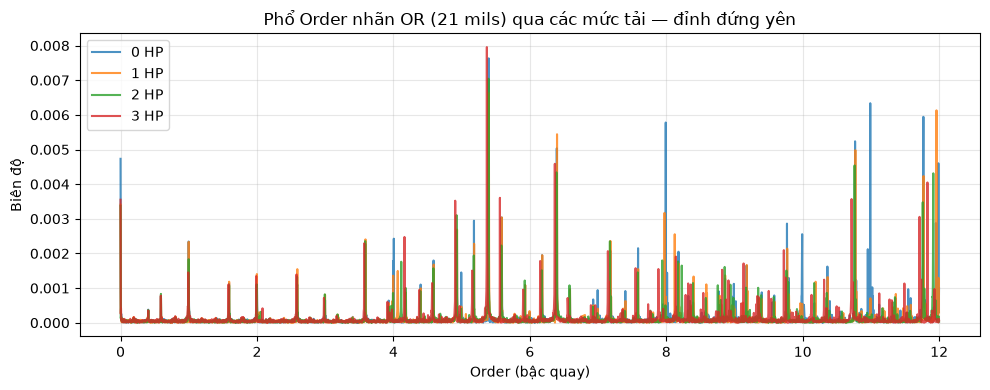

In [18]:
FAULT_LABEL = "OR"
DIAMETER_MILS = 21
ORDER_MAX = 12

fig, ax = plt.subplots(figsize=(10, 4))
for load_hp in sorted(manifest["load_hp"].dropna().unique()):
    load_hp = int(load_hp)
    try:
        fp = pipeline.pick_file(manifest, label=FAULT_LABEL, load_hp=load_hp, diameter_mils=DIAMETER_MILS)
    except ValueError:
        continue
    x = io_utils.load_de_signal(Path(fp))
    rpm = cfg.NOMINAL_RPM_BY_LOAD.get(load_hp)
    if rpm is None:
        continue

    freqs, mag = dsp.compute_fft(x, fs=12000)
    orders = cfg.hz_to_order(freqs, rpm)
    mask = orders <= ORDER_MAX
    ax.plot(orders[mask], mag[mask], label=f"{load_hp} HP", alpha=0.8)

ax.set_xlabel("Order (bậc quay)")
ax.set_ylabel("Biên độ")
ax.set_title(f"Phổ Order nhãn {FAULT_LABEL} ({DIAMETER_MILS} mils) qua các mức tải — đỉnh đứng yên")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_order_domain_across_loads.png", dpi=150)
plt.show()

## Bảng tần số lỗi lý thuyết quy đổi sang Order (phải là hằng số qua mọi tải)

In [19]:
rows = []
for load_hp, rpm in cfg.NOMINAL_RPM_BY_LOAD.items():
    freqs_hz = cfg.bearing_fault_frequencies(rpm)
    row = {"load_hp": load_hp, "rpm_danh_dinh": rpm}
    for name, f in freqs_hz.items():
        row: dict[str, Any] = {"load_hp": load_hp, "rpm_danh_dinh": rpm}
    rows.append(row)

order_table = pd.DataFrame(rows)
order_table.to_csv(TABLES_DIR / "04_theoretical_fault_order_by_load.csv", index=False)
order_table

,load_hp,rpm_danh_dinh
0,0,1797
1,1,1772
2,2,1750
3,3,1730


## Quan sát & kết luận

- Xác nhận: các cột `BPFO_order`, `BPFI_order`, `BSF_order`, `FTF_order`
  ở bảng trên phải **giống hệt nhau qua mọi dòng** (vì Order độc lập với
  RPM theo định nghĩa) — đây chính là lý do dùng Order Normalization.
- So sánh trực quan với hình `03_fft_hz_across_loads.png` (notebook 03):
  cùng 1 tín hiệu, đỉnh dịch chuyển ở trục Hz nhưng đứng yên ở trục Order.

Hình đã lưu tại `outputs/figures/04_order_domain_across_loads.png`.

---

<a id="05"></a>

## 05 — Envelope Analysis (Square-Law Demodulation)
### Mục 1.3 (minh chứng ở mục 0.2) — Giải điều chế Envelope

**Mục đích**: minh chứng vì sao cần Envelope Analysis — tín hiệu thô/phổ
thô thường **không lộ rõ** BPFO/BPFI/BSF vì bị điều biên bởi cộng hưởng cơ
khí; phổ Envelope (sau khi giải điều chế) mới bộc lộ rõ các đỉnh này.

Công thức (đúng mục 1.3 của đề cương):

```
Envelope[n] = LowPassFilter( (x[n] * h_bandpass[n])² )
```

Notebook này cũng đối chiếu nhanh với Hilbert Transform để **kiểm tra
chéo hình dạng phổ** (không phải so sánh tài nguyên — việc đó thuộc
Giai đoạn 3, đo bằng số thật qua STM32Cube.AI/ST Edge AI Cloud).

In [20]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,None,,False
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,None,,False
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,None,,False
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,None,,False
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,None,,False


## Lọc phạm vi dữ liệu (mục 0.1/0.4) — TRƯỚC khi phân tích

`manifest` gốc còn chứa cả file NGOÀI phạm vi đã chốt (vòng bi NTN đường
kính 28/40 mils, vị trí Outer Race Orthogonal/Opposite). Nếu không lọc ở
đây, các bước chọn "file đại diện" bên dưới có thể vô tình chọn nhầm — vd
chọn file OR vị trí Orthogonal/Opposite trong khi đề tài chỉ dùng Centered.

In [21]:
manifest = io_utils.apply_scope_filter(manifest)

Áp dụng bộ lọc phạm vi (mục 0.1/0.4):
  - Loại 8 file có cảnh báo 'VONG_BI_NTN'
  - Loại 47 file có cảnh báo 'OR_NGOAI_PHAM_VI'
  - Loại 0 file có cảnh báo 'OR_THIEU_VI_TRI'
  - Loại 0 file có cảnh báo 'THIEU_NHAN'
  - Loại 0 file có cảnh báo 'THIEU_TAI'
  - Loại 0 file có cảnh báo 'DUONG_KINH_LA'
  - Loại 45 file có cảnh báo 'NGOAI_PHAM_VI_CAM_BIEN'
  - Loại 52 file có cảnh báo 'NGOAI_PHAM_VI_TAN_SO_KHAI_BAO'
  - Loại 0 file có cảnh báo 'THIEU_TIN_HIEU_DE'
  - Loại 0 file có cảnh báo 'LOI_DOC_FILE'
Tổng: loại 121/161 file — còn lại 40 file.


## Chọn dải bandpass

**Việc quan trọng nhất của notebook này**: `BAND_HZ` bên dưới là giá trị
**ví dụ**, cần chỉnh lại dựa trên quan sát thực tế ở notebook 03 (vùng tần
số có biên độ nổi bật nhất) kết hợp tài liệu kỹ thuật SKF 6205, theo đúng
quyết định ở mục 0.4 của đề cương — không dùng phương pháp dò tự động
(Kurtogram/Spectral Kurtosis).

In [22]:
FAULT_LABEL = "OR"
DIAMETER_MILS = 21
LOAD_HP = 0
BAND_HZ = (1500, 3500)     # <-- CHỈNH lại dựa trên quan sát phổ thật (notebook 03)
LP_CUTOFF_HZ = 500
FREQ_MAX_PLOT = 400

fp = pipeline.pick_file(manifest, label=FAULT_LABEL, load_hp=LOAD_HP, diameter_mils=DIAMETER_MILS)
x = io_utils.load_de_signal(Path(fp))
rpm = cfg.NOMINAL_RPM_BY_LOAD[LOAD_HP]
print(f"File: {fp}")
print(f"RPM danh định: {rpm}")

File: ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\OR\021\@6\234_0.mat
RPM danh định: 1797


## Phổ Envelope (Square-Law) — đánh dấu BPFO/BPFI/BSF/FTF lý thuyết

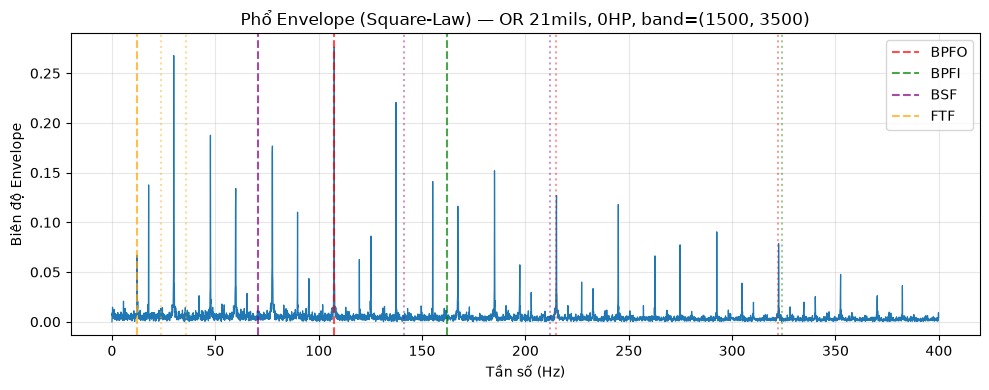

In [23]:
envelope = dsp.square_law_envelope(x, fs=12000, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
freqs, mag = dsp.compute_fft(envelope - envelope.mean(), fs=12000)
fault_freqs = cfg.bearing_fault_frequencies(rpm)

fig, ax = plt.subplots(figsize=(10, 4))
mask = freqs <= FREQ_MAX_PLOT
ax.plot(freqs[mask], mag[mask], linewidth=0.9)

colors = {"BPFO": "red", "BPFI": "green", "BSF": "purple", "FTF": "orange"}
for name, f in fault_freqs.items():
    if name == "f_rot" or f > FREQ_MAX_PLOT:
        continue
    ax.axvline(f, color=colors.get(name, "gray"), linestyle="--", alpha=0.7, label=name)
    for h in (2, 3):
        if f * h <= FREQ_MAX_PLOT:
            ax.axvline(f * h, color=colors.get(name, "gray"), linestyle=":", alpha=0.4)

ax.set_xlabel("Tần số (Hz)")
ax.set_ylabel("Biên độ Envelope")
ax.set_title(f"Phổ Envelope (Square-Law) — {FAULT_LABEL} {DIAMETER_MILS}mils, {LOAD_HP}HP, band={BAND_HZ}")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_spectrum_square_law.png", dpi=150)
plt.show()

## Đối chiếu chéo với Hilbert Transform (chỉ kiểm tra hình dạng phổ)

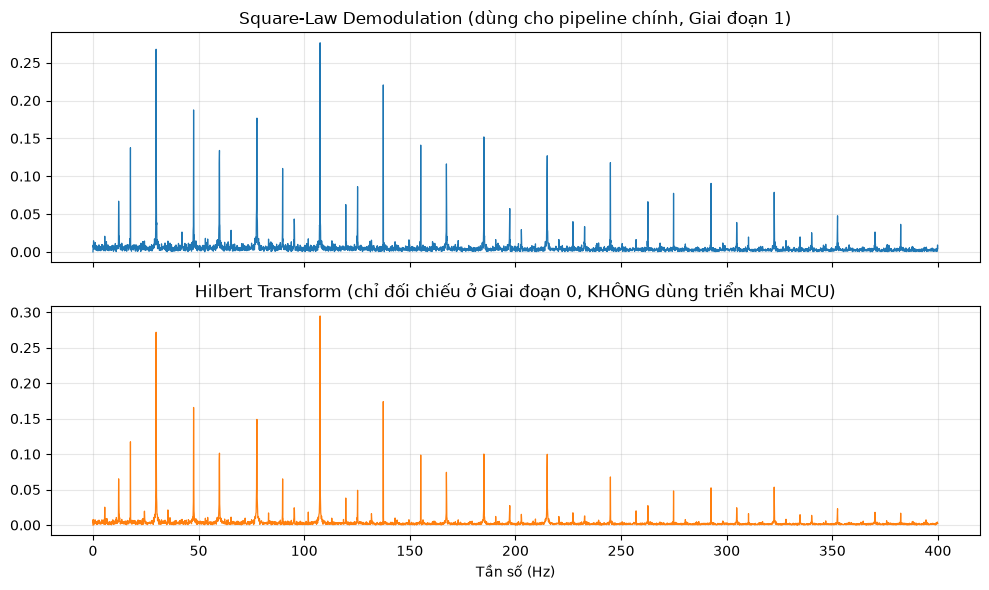

Kỳ vọng: 2 phổ có hình dạng TƯƠNG TỰ nhau (cùng vị trí đỉnh chính).
Nếu khác biệt rõ rệt, kiểm tra lại BAND_HZ hoặc bậc lọc trước khi chốt band.


In [24]:
envelope_hilbert = dsp.hilbert_envelope(x, fs=12000, band=BAND_HZ)
freqs_h, mag_h = dsp.compute_fft(envelope_hilbert - envelope_hilbert.mean(), fs=12000)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
mask = freqs <= FREQ_MAX_PLOT
axes[0].plot(freqs[mask], mag[mask], linewidth=0.9, color="tab:blue")
axes[0].set_title("Square-Law Demodulation (dùng cho pipeline chính, Giai đoạn 1)")
axes[0].grid(alpha=0.3)

mask_h = freqs_h <= FREQ_MAX_PLOT
axes[1].plot(freqs_h[mask_h], mag_h[mask_h], linewidth=0.9, color="tab:orange")
axes[1].set_title("Hilbert Transform (chỉ đối chiếu ở Giai đoạn 0, KHÔNG dùng triển khai MCU)")
axes[1].set_xlabel("Tần số (Hz)")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_squarelaw_vs_hilbert.png", dpi=150)
plt.show()

print("Kỳ vọng: 2 phổ có hình dạng TƯƠNG TỰ nhau (cùng vị trí đỉnh chính).")
print("Nếu khác biệt rõ rệt, kiểm tra lại BAND_HZ hoặc bậc lọc trước khi chốt band.")

## Quan sát & quyết định

- Ghi lại `BAND_HZ` cuối cùng đã chốt và lý do (quan sát phổ + tài liệu
  SKF 6205) — đây là thông tin bắt buộc phải có trong báo cáo (mục 0.4).
- Xác nhận đỉnh BPFO/BPFI/BSF (tùy nhãn đang xét) lộ rõ hơn hẳn so với phổ
  thô ở notebook 03.

Hình đã lưu tại `outputs/figures/05_envelope_spectrum_square_law.png` và
`05_envelope_squarelaw_vs_hilbert.png`.

---

<a id="06"></a>

## 06 — Window Leakage Analysis
### Mục 0.3 (phần 1) — Rò rỉ dữ liệu do Sliding Window

**Mục đích**: minh họa bằng số **bản chất** của rò rỉ dữ liệu khi chia
ngẫu nhiên theo sliding window, và chạy thực nghiệm nhỏ đối chiếu Random
Window Split vs File-based Split — bằng chứng thực nghiệm **sơ bộ** cho
RQ1/H1 (kết quả đầy đủ, chính thức vẫn báo cáo lại ở Giai đoạn 4 với bể
đặc trưng đầy đủ và LOLO 4-fold).

**Lưu ý phương pháp quan trọng**: minh họa dưới đây đo **tỉ lệ mẫu thô
thực sự trùng nhau** giữa 2 window liền kề (một sự thật xác định) và
**chênh lệch đặc trưng thống kê** giữa chúng — KHÔNG dùng hệ số tương quan
Pearson so theo vị trí chỉ số (`corrcoef(w1, w2)`), vì cách đó có thể cho
số liệu sai lệch/gây hiểu nhầm khi tín hiệu có thành phần tuần hoàn lệch
pha ngẫu nhiên với bước dịch cửa sổ.

In [25]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,None,,False
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,None,,False
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,None,,False
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,None,,False
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,None,,False


## Lọc phạm vi dữ liệu (mục 0.1/0.4) — TRƯỚC khi phân tích

`manifest` gốc còn chứa cả file NGOÀI phạm vi đã chốt (vòng bi NTN đường
kính 28/40 mils, vị trí Outer Race Orthogonal/Opposite). Nếu không lọc ở
đây, các bước chọn "file đại diện" bên dưới có thể vô tình chọn nhầm — vd
chọn file OR vị trí Orthogonal/Opposite trong khi đề tài chỉ dùng Centered.

In [26]:
manifest = io_utils.apply_scope_filter(manifest)

Áp dụng bộ lọc phạm vi (mục 0.1/0.4):
  - Loại 8 file có cảnh báo 'VONG_BI_NTN'
  - Loại 47 file có cảnh báo 'OR_NGOAI_PHAM_VI'
  - Loại 0 file có cảnh báo 'OR_THIEU_VI_TRI'
  - Loại 0 file có cảnh báo 'THIEU_NHAN'
  - Loại 0 file có cảnh báo 'THIEU_TAI'
  - Loại 0 file có cảnh báo 'DUONG_KINH_LA'
  - Loại 45 file có cảnh báo 'NGOAI_PHAM_VI_CAM_BIEN'
  - Loại 52 file có cảnh báo 'NGOAI_PHAM_VI_TAN_SO_KHAI_BAO'
  - Loại 0 file có cảnh báo 'THIEU_TIN_HIEU_DE'
  - Loại 0 file có cảnh báo 'LOI_DOC_FILE'
Tổng: loại 121/161 file — còn lại 40 file.


## Minh họa 1 — Tỉ lệ mẫu trùng & chênh lệch đặc trưng giữa 2 window liền kề

In [27]:
def demo_window_overlap_similarity(signal, window_size, overlap_ratio):
    step = max(int(window_size * (1 - overlap_ratio)), 1)
    w1 = signal[0: window_size]
    w2 = signal[step: step + window_size]

    shared_fraction = max(0, window_size - step) / window_size
    f1 = features.extract_simple_features(w1)
    f2 = features.extract_simple_features(w2)

    print(f"Overlap cấu hình = {overlap_ratio*100:.0f}%  (step={step}, window={window_size})")
    print(f"  -> Tỉ lệ MẪU THÔ trùng nhau: {shared_fraction*100:.1f}%")
    print("  -> Chênh lệch đặc trưng thống kê giữa 2 window:")
    for name in f1:
        rel_diff = abs(f1[name] - f2[name]) / (abs(f1[name]) + 1e-8) * 100
        print(f"       {name:10s}: {rel_diff:6.2f}% chênh lệch")
    print()
    return shared_fraction

fp = pipeline.pick_file(manifest, label="OR", load_hp=0)
demo_signal = io_utils.load_de_signal(Path(fp))

for overlap in (0.9, 0.75, 0.5, 0.0):
    demo_window_overlap_similarity(demo_signal, window_size=2048, overlap_ratio=overlap)

Overlap cấu hình = 90%  (step=204, window=2048)
  -> Tỉ lệ MẪU THÔ trùng nhau: 90.0%
  -> Chênh lệch đặc trưng thống kê giữa 2 window:
       rms       :   0.87% chênh lệch
       kurtosis  :   2.16% chênh lệch
       skewness  :  18.95% chênh lệch
       peak      :   0.00% chênh lệch
       std       :   0.87% chênh lệch

Overlap cấu hình = 75%  (step=512, window=2048)
  -> Tỉ lệ MẪU THÔ trùng nhau: 75.0%
  -> Chênh lệch đặc trưng thống kê giữa 2 window:
       rms       :   1.55% chênh lệch
       kurtosis  :   3.37% chênh lệch
       skewness  :  24.15% chênh lệch
       peak      :   0.00% chênh lệch
       std       :   1.56% chênh lệch

Overlap cấu hình = 50%  (step=1024, window=2048)
  -> Tỉ lệ MẪU THÔ trùng nhau: 50.0%
  -> Chênh lệch đặc trưng thống kê giữa 2 window:
       rms       :   0.17% chênh lệch
       kurtosis  :   0.15% chênh lệch
       skewness  :  14.44% chênh lệch
       peak      :   0.00% chênh lệch
       std       :   0.17% chênh lệch

Overlap cấu hình = 0%

## Minh họa 2 — Thực nghiệm so sánh Random Window Split vs File-based Split

Cắt sliding window (overlap 75%) trên **toàn bộ** file trong manifest,
trích 5 đặc trưng đơn giản, huấn luyện Random Forest theo 2 cách chia,
so sánh accuracy.

In [28]:
WINDOW_SIZE = 2048
OVERLAP_RATIO = 0.75

all_windows = []
for _, row in manifest.iterrows():
    if row["label"] is None or pd.isna(row["label"]):
        continue
    x = io_utils.load_de_signal(Path(row["file_path"]))
    file_id = f"{row['label']}_{row['load_hp']}_{row.get('fault_diameter_mils')}_{row['file_path']}"
    w = features.make_sliding_windows(x, WINDOW_SIZE, OVERLAP_RATIO, file_id=file_id, label=row["label"])
    all_windows.append(w)

windows_df = pd.concat(all_windows, ignore_index=True)
feature_df = features.build_feature_table(windows_df)
feature_cols = ["rms", "kurtosis", "skewness", "peak", "std"]
print(f"Tổng số window: {len(feature_df)}  (từ {feature_df['file_id'].nunique()} file)")

Tổng số window: 11752  (từ 40 file)


In [29]:
result_df = splitting.run_split_comparison_experiment(feature_df, feature_cols)
result_df.to_csv(TABLES_DIR / "06_split_comparison.csv")

delta = (
    float(result_df.loc["Random Window Split (SAI)", "accuracy"]) -  # type: ignore
    float(result_df.loc["File-based Split (ĐÚNG)", "accuracy"]) # type: ignore
)

print(result_df)
print(f"\nΔAccuracy (ảo) = {delta:.4f}")
print("Dương và đáng kể -> khớp chiều với H1: Random Window Split cho "
      "accuracy cao hơn ảo do rò rỉ dữ liệu.")

                           accuracy  f1_macro  n_train  n_test
Random Window Split (SAI)  0.986383  0.985833   8227.0  3525.0
File-based Split (ĐÚNG)    0.874003  0.853246   7990.0  3762.0

ΔAccuracy (ảo) = 0.1124
Dương và đáng kể -> khớp chiều với H1: Random Window Split cho accuracy cao hơn ảo do rò rỉ dữ liệu.


## Quan sát & kết luận sơ bộ

- Ghi lại ΔAccuracy quan sát được — đây là bằng chứng **sơ bộ** cho RQ1/H1.
- Kết quả **chính thức** để đưa vào Bảng 1 của báo cáo (mục 4.1) phải chạy
  lại ở Giai đoạn 4 với: (a) bể đặc trưng đầy đủ (mục 1.4, không chỉ 5 đặc
  trưng đơn giản ở đây), và (b) File-based Split + LOLO đầy đủ 4-fold
  (không chỉ 1 lần chia ngẫu nhiên như demo này).

> ⚠️ **Vì sao ΔAccuracy có thể RẤT NHỎ khi chạy với `USE_SYNTHETIC_DATA =
> True`?** Tín hiệu giả lập trong `common/synthetic.py` tạo ra các lớp
> tách biệt rất rõ ràng (mỗi lỗi có 1 tần số xung riêng biệt, không nhiễu
> chồng lấp giữa các lớp) — cả 2 cách chia đều dễ dàng đạt gần 100%
> accuracy ("hiệu ứng trần"/ceiling effect), khiến chênh lệch do rò rỉ dữ
> liệu bị che khuất dù nó vẫn tồn tại về bản chất (xem lại Minh họa 1 ở
> trên — tỉ lệ mẫu trùng và chênh lệch đặc trưng vẫn rất rõ). **Đây KHÔNG
> phải bằng chứng phản bác H1.** Với dữ liệu CWRU thật (nhiễu cơ khí thật,
> ranh giới giữa các lớp mờ hơn nhiều), y văn báo cáo chênh lệch do rò rỉ
> thường rất đáng kể (accuracy ảo >99% so với accuracy tổng quát hóa thấp
> hơn nhiều) — đây chính là động lực ban đầu của đề tài (xem mục 0 —
> Bối cảnh và động lực nghiên cứu). Chạy lại notebook này với dữ liệu thật
> để có con số đáng tin cậy.

Bảng kết quả đã lưu tại `outputs/tables/06_split_comparison.csv`.

---

<a id="07"></a>

## 07 — Leave-One-Load-Out (LOLO) Visualization
### Mục 0.3 (phần 2) — Trực quan hóa cấu trúc kiểm định LOLO

**Mục đích**: trực quan hóa cấu trúc 4-fold LOLO (định nghĩa chính thức ở
mục 2.1 của đề cương) và kiểm tra độ cân bằng số file giữa các mức tải
trước khi dùng làm cấu trúc kiểm định chính thức cho toàn đề tài.

Hàm `generate_lolo_folds()` dùng ở đây được **import nguyên vẹn** từ
`common/splitting.py` — dùng lại y hệt ở Giai đoạn 1-2, không viết lại lần
thứ hai để tránh lệch cấu trúc giữa các giai đoạn.

**Giới hạn cần nhớ (mục 0.4 của đề cương)**: LOLO trên CWRU đo tổng quát
hóa qua **điều kiện tải**, không phải qua **vòng bi vật lý độc lập** — vì
CWRU dùng chung 1 vòng bi qua nhiều mức tải liên tiếp.

In [30]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,None,,False
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,None,,False
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,None,,False
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,None,,False
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,None,,False


## Lọc phạm vi dữ liệu (mục 0.1/0.4) — TRƯỚC khi phân tích

`manifest` gốc còn chứa cả file NGOÀI phạm vi đã chốt (vòng bi NTN đường
kính 28/40 mils, vị trí Outer Race Orthogonal/Opposite). Nếu không lọc ở
đây, các bước chọn "file đại diện" bên dưới có thể vô tình chọn nhầm — vd
chọn file OR vị trí Orthogonal/Opposite trong khi đề tài chỉ dùng Centered.

In [31]:
manifest = io_utils.apply_scope_filter(manifest)

Áp dụng bộ lọc phạm vi (mục 0.1/0.4):
  - Loại 8 file có cảnh báo 'VONG_BI_NTN'
  - Loại 47 file có cảnh báo 'OR_NGOAI_PHAM_VI'
  - Loại 0 file có cảnh báo 'OR_THIEU_VI_TRI'
  - Loại 0 file có cảnh báo 'THIEU_NHAN'
  - Loại 0 file có cảnh báo 'THIEU_TAI'
  - Loại 0 file có cảnh báo 'DUONG_KINH_LA'
  - Loại 45 file có cảnh báo 'NGOAI_PHAM_VI_CAM_BIEN'
  - Loại 52 file có cảnh báo 'NGOAI_PHAM_VI_TAN_SO_KHAI_BAO'
  - Loại 0 file có cảnh báo 'THIEU_TIN_HIEU_DE'
  - Loại 0 file có cảnh báo 'LOI_DOC_FILE'
Tổng: loại 121/161 file — còn lại 40 file.


## Cấu trúc 4 fold

In [32]:
folds = splitting.generate_lolo_folds(loads=(0, 1, 2, 3))
for fold in folds:
    print(f"Test = tải {{{fold['test_load']}}}  |  Train/Val = tải {fold['trainval_loads']}")

Test = tải {0}  |  Train/Val = tải [1, 2, 3]
Test = tải {1}  |  Train/Val = tải [0, 2, 3]
Test = tải {2}  |  Train/Val = tải [0, 1, 3]
Test = tải {3}  |  Train/Val = tải [0, 1, 2]


## Sơ đồ trực quan cấu trúc LOLO

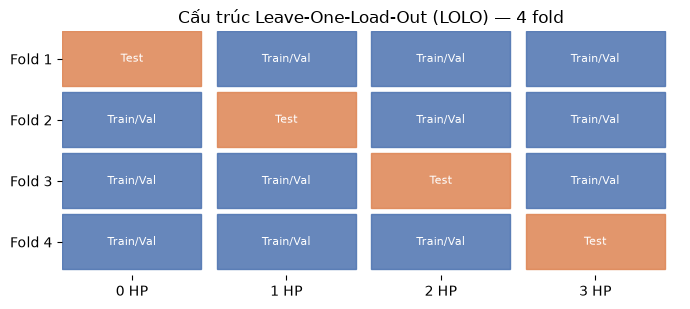

In [33]:
loads = [0, 1, 2, 3]
fig, ax = plt.subplots(figsize=(7, 3.2))

color_trainval = "#4C72B0"
color_test = "#DD8452"

for fold_idx, fold in enumerate(folds):
    for load in loads:
        is_test = (load == fold["test_load"])
        color = color_test if is_test else color_trainval
        
        ax.add_patch(Rectangle((load, fold_idx), 0.9, 0.9, color=color, alpha=0.85))
        label = "Test" if is_test else "Train/Val"
        ax.text(load + 0.45, fold_idx + 0.45, label, ha="center", va="center",
                fontsize=8, color="white")

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_xticks([l + 0.45 for l in loads])
ax.set_xticklabels([f"{l} HP" for l in loads])
ax.set_yticks([i + 0.45 for i in range(4)])
ax.set_yticklabels([f"Fold {i+1}" for i in range(4)])
ax.set_title("Cấu trúc Leave-One-Load-Out (LOLO) — 4 fold")
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_lolo_structure.png", dpi=150)
plt.show()

## Kiểm tra cân bằng số file giữa các mức tải (ảnh hưởng trực tiếp đến từng fold)

load_hp
0    10
1    10
2    10
3    10
Name: file_path, dtype: int64


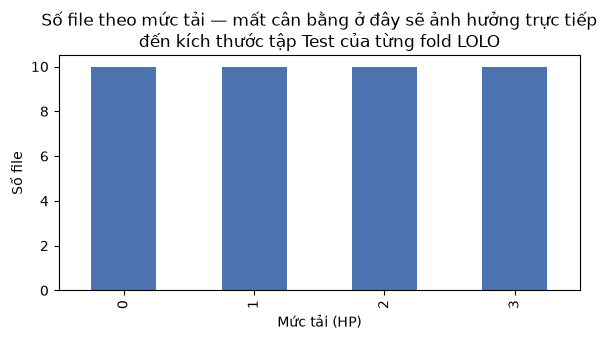


Tỉ lệ lệch lớn nhất giữa các tải: 1.00x
=> Tương đối cân bằng giữa các tải.


In [34]:
counts_by_load = manifest.groupby("load_hp")["file_path"].count()
print(counts_by_load)

fig, ax = plt.subplots(figsize=(6, 3.5))
counts_by_load.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Mức tải (HP)")
ax.set_ylabel("Số file")
ax.set_title("Số file theo mức tải — mất cân bằng ở đây sẽ ảnh hưởng trực tiếp\nđến kích thước tập Test của từng fold LOLO")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_file_count_by_load.png", dpi=150)
plt.show()

max_ratio = counts_by_load.max() / counts_by_load.min()
print(f"\nTỉ lệ lệch lớn nhất giữa các tải: {max_ratio:.2f}x")
if max_ratio > 1.5:
    print("=> Lệch đáng kể — cân nhắc ghi chú ảnh hưởng này khi phân tích "
          "kết quả từng fold ở Giai đoạn 2 (mục 2.1: fold nào thấp hơn hẳn "
          "cần được phân tích nguyên nhân).")
else:
    print("=> Tương đối cân bằng giữa các tải.")

## Ghi chú cho báo cáo

- Sơ đồ `07_lolo_structure.png` dùng trực tiếp minh họa mục 2.1 của báo cáo.
- Nếu số file lệch đáng kể giữa các tải, cần nêu rõ trong phần Thảo luận
  khi một fold LOLO cho kết quả thấp hơn hẳn các fold còn lại.
- Nhắc lại giới hạn LOLO trên CWRU (đã nêu ở mục 0.4/Phạm vi & giới hạn) —
  nên đặt ngay cạnh sơ đồ này trong báo cáo để người đọc không hiểu nhầm
  đây là kiểm định qua vòng bi độc lập.

---

<a id="08"></a>

## 08 — Summary & Research Questions
### Mục 0.4 — Hình thành giả thuyết nghiên cứu & Tổng kết Giai đoạn 0

**Mục đích**: tổng hợp kết quả từ 7 notebook trước, xác nhận Giai đoạn 0
đã hoàn chỉnh, và trình bày lại 5 câu hỏi nghiên cứu (RQ1–RQ5) cùng giả
thuyết tương ứng (H1–H5) — cầu nối chuyển sang thiết kế pipeline chính
thức ở Giai đoạn 1–4.

Notebook này **không tạo phân tích mới** — chỉ tổng hợp lại output đã lưu
từ các notebook 01–07. Nếu có ô báo lỗi "không tìm thấy file", quay lại
chạy notebook tương ứng trước.

## 1. Tổng quan manifest

In [35]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=False,   # dùng lại manifest đã build ở notebook 01
)

n_total = len(manifest)
n_warn = int(manifest["has_warning"].sum())
print(f"Tổng số file trong manifest : {n_total}")
print(f"Số file có cảnh báo         : {n_warn} ({n_warn/max(n_total,1)*100:.1f}%)")

print("\nSố file theo (nhãn x tải):")
print(manifest.pivot_table(index="label", columns="load_hp", values="file_path", aggfunc="count", fill_value=0))

Tổng số file trong manifest : 161
Số file có cảnh báo         : 125 (77.6%)

Số file theo (nhãn x tải):
load_hp   0   1   2   3
label                  
B        10  10  10  10
IR       10  10  10  10
Normal    1   1   1   1
OR       20  19  19  19


In [36]:
# Đếm số lần xuất hiện theo LOẠI cảnh báo (parse từ cột warnings)
warning_keywords = [
    "NGHI_NGO_SAMPLING_RATE", "THOI_LUONG_BAT_THUONG", "RPM_LECH",
    "VONG_BI_NTN", "DUONG_KINH_LA", "OR_THIEU_VI_TRI", "OR_NGOAI_PHAM_VI",
    "THIEU_NHAN", "THIEU_TAI",
]
all_warnings_text = " ".join(manifest["warnings"].fillna("").tolist())
counts = {kw: all_warnings_text.count(kw) for kw in warning_keywords}
counts_df = pd.Series(counts, name="so_lan_xuat_hien").sort_values(ascending=False)
counts_df.to_csv(TABLES_DIR / "08_warning_counts_summary.csv")
counts_df[counts_df > 0]

OR_NGOAI_PHAM_VI          47
NGHI_NGO_SAMPLING_RATE    16
VONG_BI_NTN                8
RPM_LECH                   1
THOI_LUONG_BAT_THUONG      1
Name: so_lan_xuat_hien, dtype: int64

## 2. Các hình minh chứng đã tạo (notebook 02–05, 07)

--- So sánh dạng sóng thời gian (notebook 02) ---


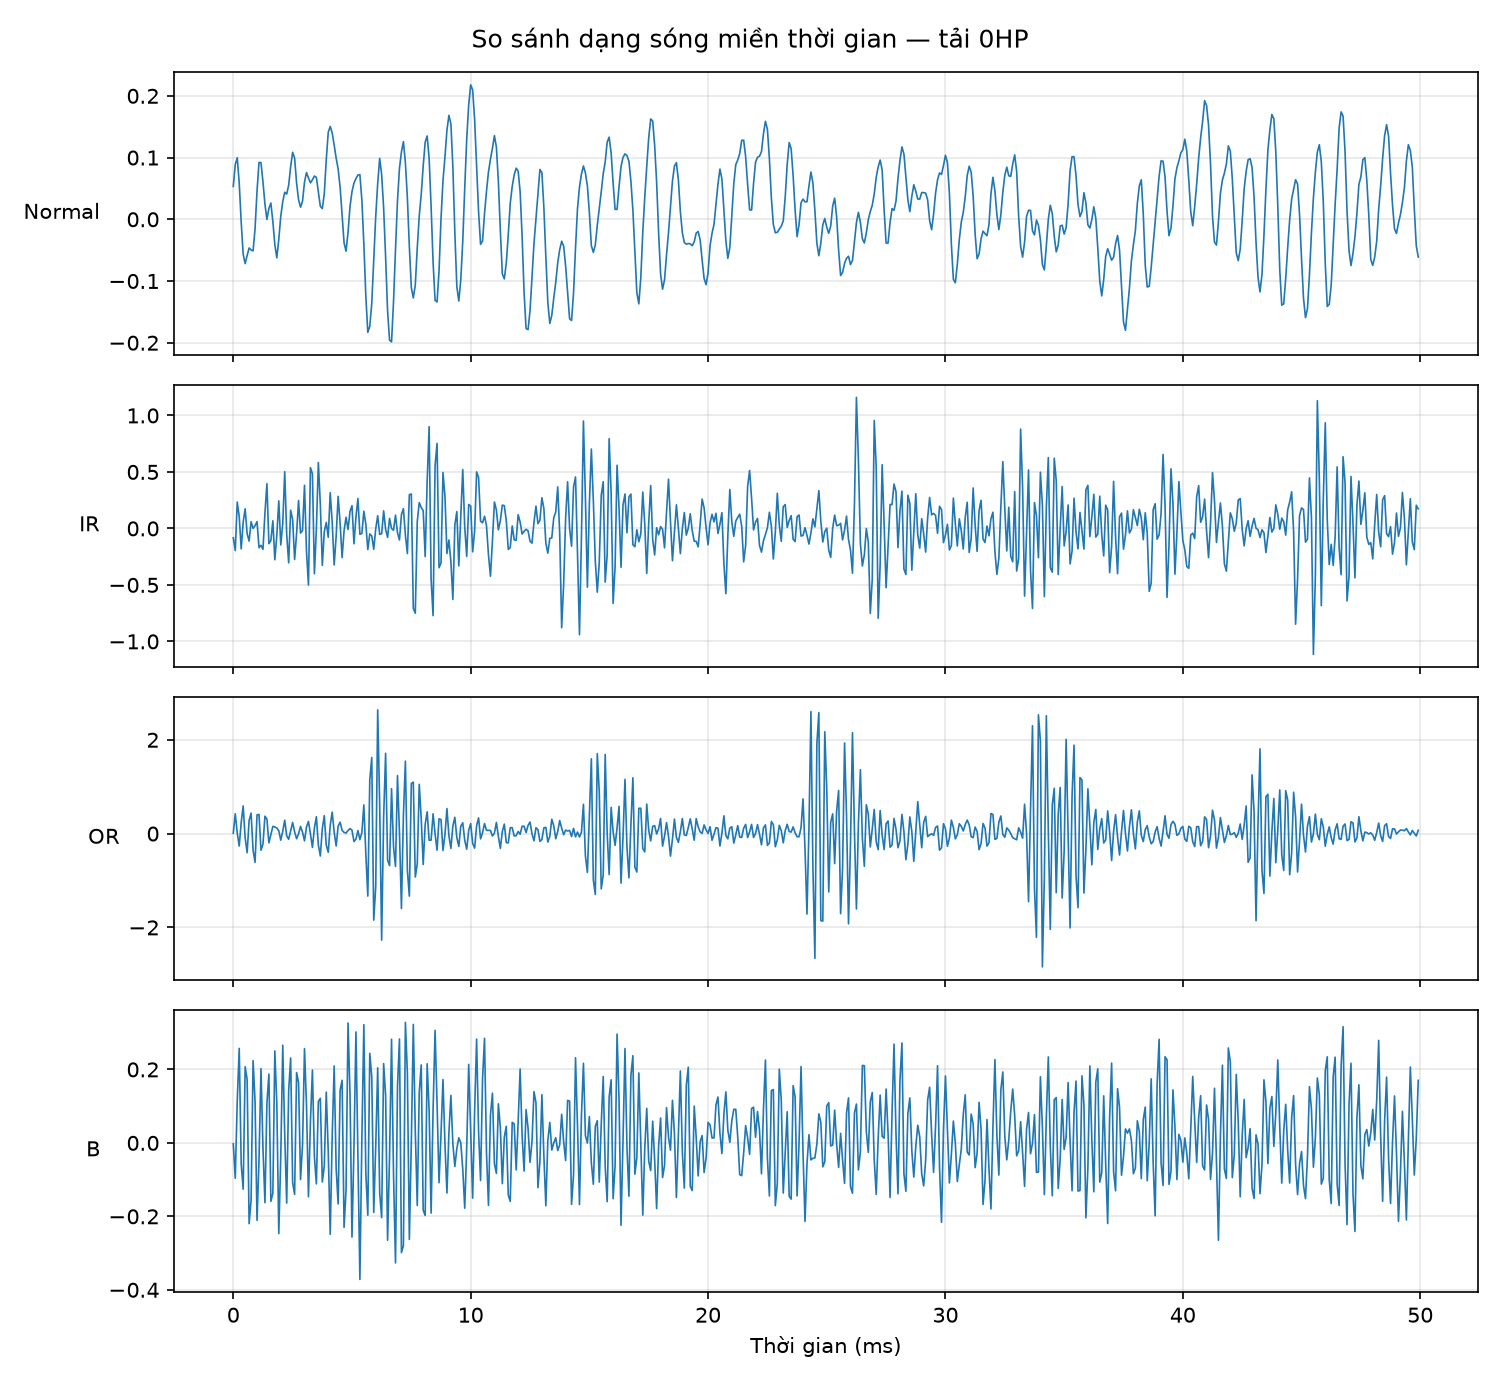


--- FFT trục Hz qua các tải (notebook 03) ---


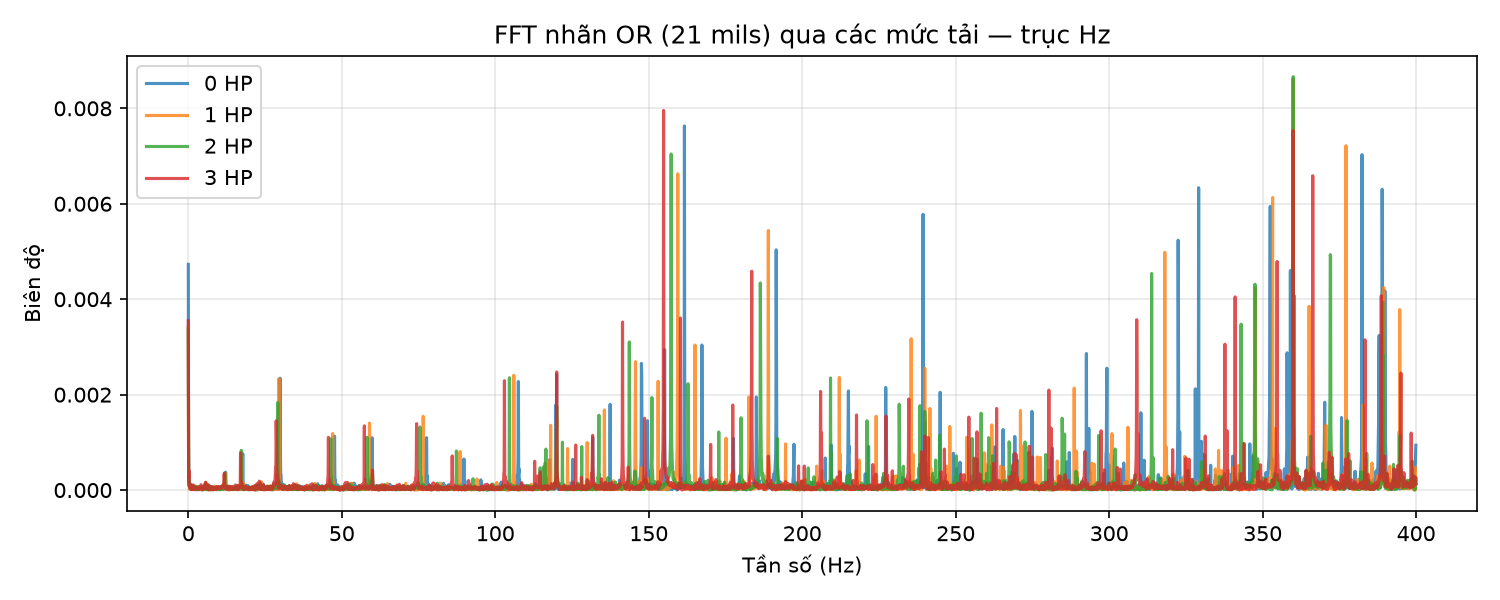


--- Phổ Order qua các tải (notebook 04) ---


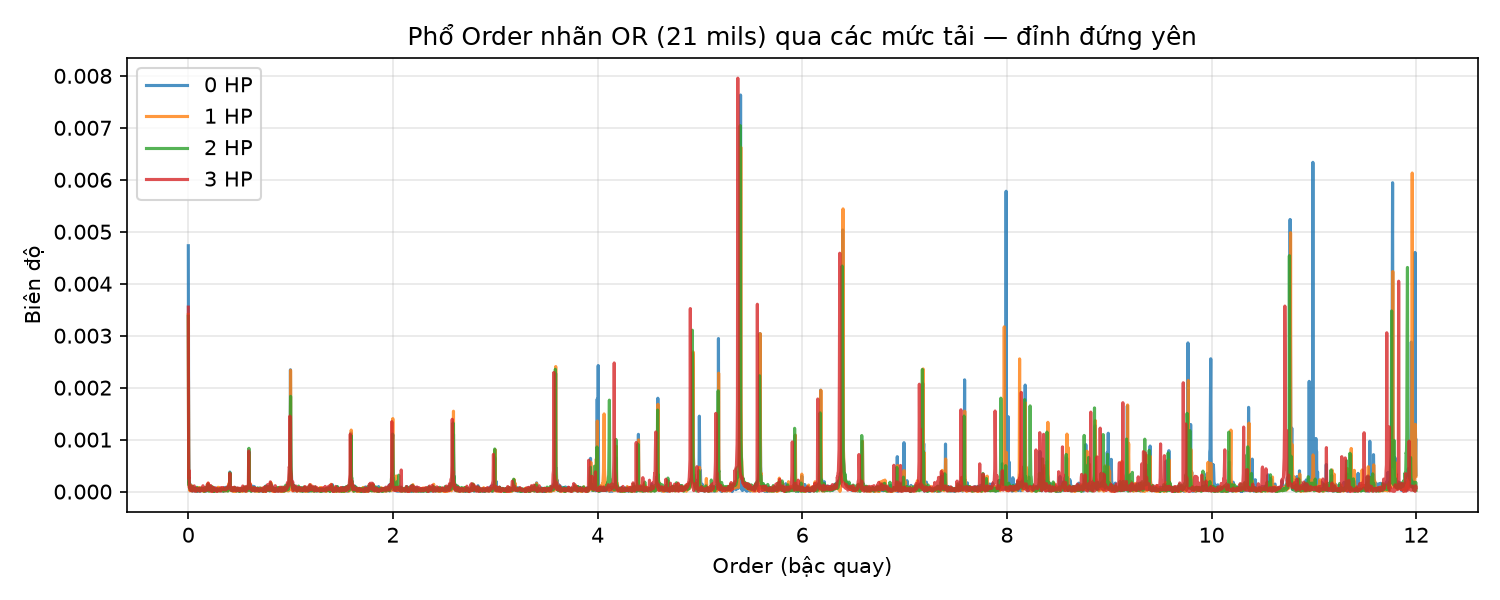


--- Phổ Envelope Square-Law (notebook 05) ---


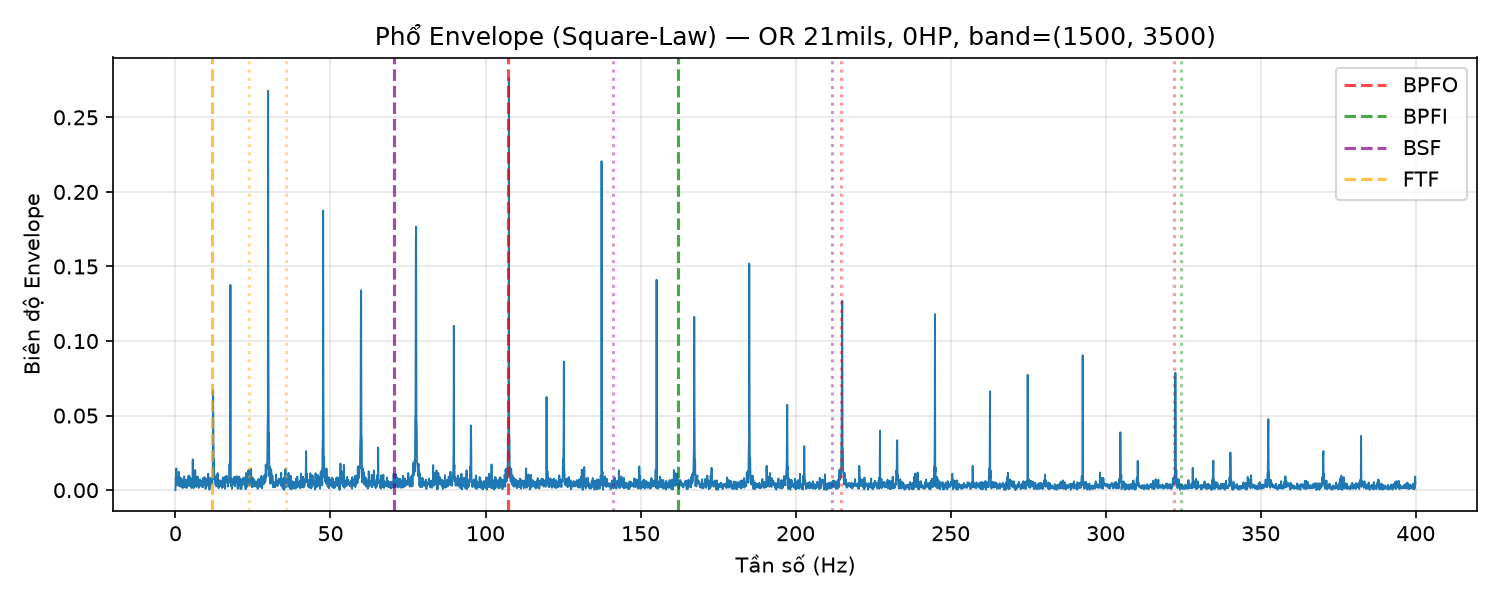


--- Cấu trúc 4-fold LOLO (notebook 07) ---


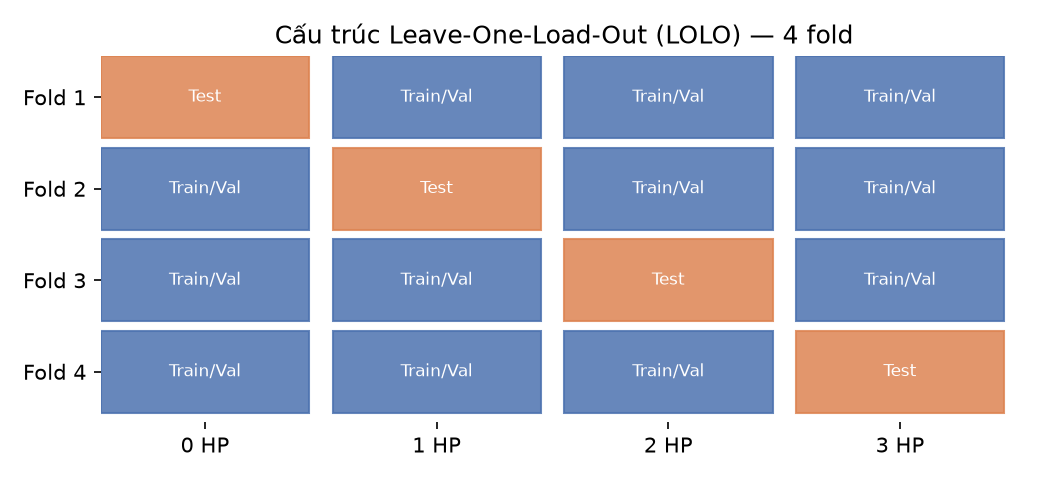

In [37]:
figure_files = [
    ("02_time_domain_comparison.png", "So sánh dạng sóng thời gian (notebook 02)"),
    ("03_fft_hz_across_loads.png", "FFT trục Hz qua các tải (notebook 03)"),
    ("04_order_domain_across_loads.png", "Phổ Order qua các tải (notebook 04)"),
    ("05_envelope_spectrum_square_law.png", "Phổ Envelope Square-Law (notebook 05)"),
    ("07_lolo_structure.png", "Cấu trúc 4-fold LOLO (notebook 07)"),
]

for fname, caption in figure_files:
    fpath = FIGURES_DIR / fname
    print(f"--- {caption} ---")
    if fpath.exists():
        display(Image(filename=str(fpath)))
    else:
        print(f"  [chưa có — chạy notebook tương ứng trước] {fpath}")
    print()

## 3. Research Questions & Hypotheses

Bảng dưới đây trình bày lại 5 câu hỏi nghiên cứu chính thức của đề tài —
hình thành từ quan sát thực nghiệm ở notebook 01–07.

| RQ | Nội dung | Giả thuyết (H) | Thực nghiệm | Notebook liên quan |
|---|---|---|---|---|
| **RQ1** | Chênh lệch accuracy giữa Random Window Split và File-based Split + LOLO trên CWRU là bao nhiêu? | **H1**: Random Window Split cho accuracy cao hơn đáng kể (ảo) do rò rỉ dữ liệu | Bảng 1 (Giai đoạn 4) | 06 (sơ bộ) |
| **RQ2** | MLP trên đặc trưng chọn lọc (Order + Envelope) có đạt/vượt CNN1D học trực tiếp từ tín hiệu thô không? | **H2**: MLP cạnh tranh được với CNN1D, ổn định hơn qua các fold LOLO (CNN1D dễ overfit hơn trên tập nhỏ) | Giai đoạn 2.3 | 07 (cấu trúc LOLO dùng chung) |
| **RQ3** | Rút gọn ~30 đặc trưng ảnh hưởng thế nào đến accuracy và RAM/MACC? | **H3**: RAM/MACC giảm đáng kể, accuracy giảm không đáng kể (có thể tăng nhẹ) | Bảng 2 (Giai đoạn 4) | — (Giai đoạn 2.2) |
| **RQ4** | Square-Law Demodulation tiết kiệm bao nhiêu thời gian/RAM so với Hilbert Transform trên ARM Cortex-M? | **H4**: Nhanh hơn và nhẹ RAM hơn đáng kể (không cần FFT/IFFT, buffer số phức) | Bảng 3a (Giai đoạn 4) | 05 (kiểm tra chéo hình dạng phổ) |
| **RQ5** | Goertzel có lợi cả tốc độ lẫn RAM so với FFT toàn dải, hay chỉ một trong hai? | **H5**: Nếu M > log₂(N), chỉ lợi RAM, không chắc lợi tốc độ | Bảng 3b (Giai đoạn 4) | — (Giai đoạn 3) |

*(RQ4, RQ5 đo tài nguyên **thật** qua STM32Cube.AI / ST Edge AI Cloud —
notebook 05 chỉ kiểm tra chéo hình dạng phổ, không đo tài nguyên.)*

## 4. Checklist trước khi chuyển sang Giai đoạn 1

- [ ] Đã chỉnh `parse_metadata_from_filename()` khớp đúng với dữ liệu thật
      (notebook 01), xác nhận bằng cách so ngẫu nhiên vài dòng manifest với
      bảng tra cứu gốc trên trang CWRU.
- [ ] Đã đọc hết cảnh báo trong `outputs/tables/01_warnings.csv`, quyết
      định rõ giữ/loại từng trường hợp (đặc biệt: file 28/40 mils dùng
      NTN, vị trí OR ngoài Centered, file Normal sai sampling rate).
- [ ] Đã chọn xong `BAND_HZ` cho Square-Law Demodulation dựa trên quan sát
      phổ thật ở notebook 03/05 (không dùng giá trị mặc định trong code mẫu).
- [ ] Đã lưu các hình notebook 02–05, 07 để dùng trực tiếp trong phần Cơ sở
      lý thuyết của báo cáo.
- [ ] Đã chạy notebook 06 bằng dữ liệu **thật** (không chỉ giả lập), có
      ΔAccuracy sơ bộ thật để đối chiếu với kết quả chính thức ở Giai đoạn 4.
- [ ] Đã kiểm tra độ cân bằng file giữa các tải (notebook 07) và ghi chú
      nếu có lệch đáng kể.

## 5. Kết luận Giai đoạn 0

Toàn bộ quyết định thiết kế của Giai đoạn 1–4 (phạm vi dữ liệu, dải
bandpass, cấu trúc LOLO, 5 câu hỏi nghiên cứu) đều bắt nguồn từ quan sát
thực nghiệm trong 7 notebook trên — không phải giả định trước. Khi checklist
ở mục 4 đã hoàn tất, dữ liệu và pipeline đã sẵn sàng cho Giai đoạn 1.